# Clustering Project

## 1. Data Prep

In [29]:
# a. Read in the data file wholesale_clients.csv
import pandas as pd
data=pd.read_csv('../Data/wholesale_clients.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [30]:
data.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [31]:
# b. Remove the Channel (restaurant, hotel, etc.) and Region columns since they are not fields we want to model on
data=data.drop(['Channel','Region'],axis=1)
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [32]:
# c. Note the number of rows and columns
data.shape

(440, 6)

In [92]:
# d. Standardize the data
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
data_scaled=sc.fit_transform(data)

In [45]:
data_scaled=pd.DataFrame(data_scaled,columns=data.columns)
data_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [46]:
# e. Double check that all the column means are 0 and standard deviations are 1
data_scaled.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


## 2. K-Means Clustering

In [47]:
# a. Import KMeans and write a loop to fit models with 2 to 15 clusters
from sklearn.cluster import KMeans

inertia_values=[]
for k in range(2,16):
    kmeans=KMeans(n_clusters=k,n_init=10)
    kmeans.fit(data_scaled)
    inertia_values.append(kmeans.inertia_)

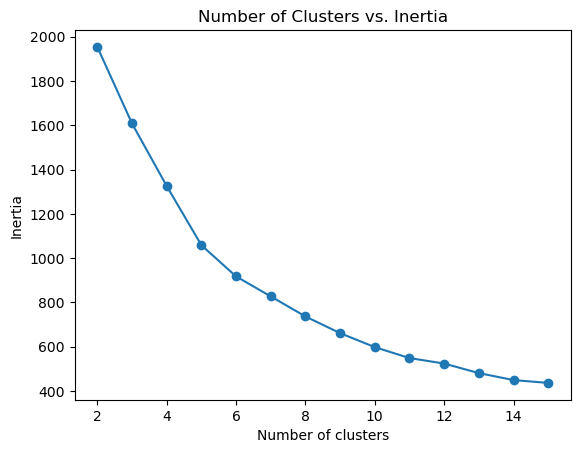

In [48]:
# b. Create an inertia plot
import matplotlib.pyplot as plt

inertia_series=pd.Series(inertia_values,index=range(2,16))

inertia_series.plot(marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title("Number of Clusters vs. Inertia");           


In [49]:
# c. Identify the elbow of the plot and fit a KMeans model just for that number of clusters
kmeans5=KMeans(n_clusters=5,n_init='auto',random_state=42)
kmeans5.fit(data_scaled)

KMeans(n_clusters=5, random_state=42)

In [50]:
# d. Find the number of clients in each cluster
from collections import Counter

Counter(kmeans5.labels_)

Counter({np.int32(3): 272,
         np.int32(0): 96,
         np.int32(1): 59,
         np.int32(2): 11,
         np.int32(4): 2})

In [51]:
data_scaled.columns

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='object')

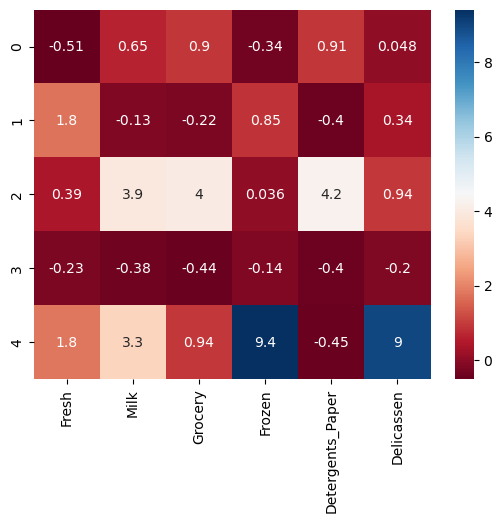

In [52]:
# e. Create a heat map of the cluster centers
import seaborn as sns

cluster_centers5 = pd.DataFrame(kmeans5.cluster_centers_, columns=data_scaled.columns)
sns.heatmap(cluster_centers5, cmap='RdBu', annot=True);

In [53]:
# f. Name the clusters
# Cluster0 -  milk - Detergent_Paper -Grocery
# Cluster1 - Fresh and Frozen
# cluster 2-  More of everything
# cluster 3 - little of everything
# cluster 4-  frozen and deli 

In [55]:
# g. Extra credit: create a silhouette scores plot instead of an inertia plot
from sklearn.metrics import silhouette_score
silhouette_scores=[]

for k in range(2,16):
    kmeans=KMeans(n_clusters=k,n_init=100)
    kmeans.fit(data_scaled)
    silhouette_scores.append(silhouette_score(data_scaled, kmeans.labels_, metric='euclidean', sample_size=None))

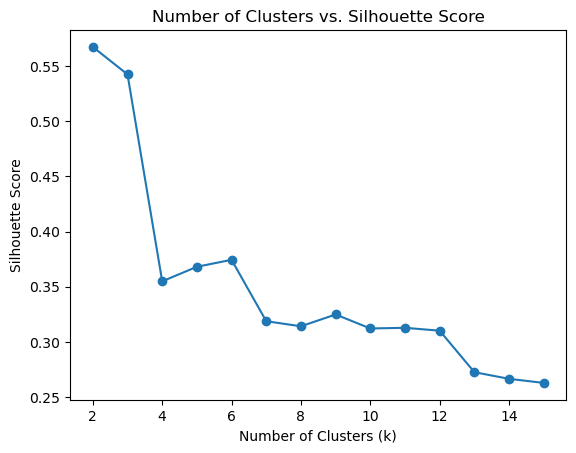

In [56]:
# plot the silhouette scores

# turn the list into a series for plotting
silhouette_series = pd.Series(silhouette_scores, index=range(2, 16))

# plot the data
silhouette_series.plot(marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Number of Clusters vs. Silhouette Score");

In [57]:
# h. Extra credit: fit two models with the number of clusters for the two highest silhouette scores and name the clusters
kmeans2=KMeans(n_clusters=2,n_init='auto',random_state=42)
kmeans2.fit(data_scaled)

KMeans(n_clusters=2, random_state=42)

In [58]:
Counter(kmeans2.labels_)

Counter({np.int32(0): 373, np.int32(1): 67})

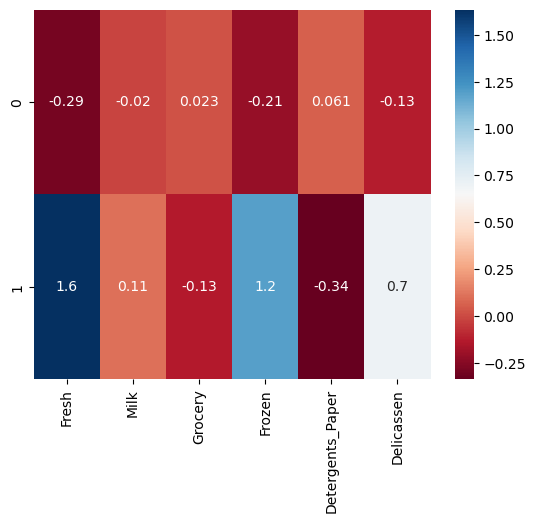

In [59]:
cluster_centers2 = pd.DataFrame(kmeans2.cluster_centers_, columns=data_scaled.columns)
sns.heatmap(cluster_centers2, cmap='RdBu', annot=True);

In [60]:
kmeans3=KMeans(n_clusters=3,n_init='auto',random_state=42)
kmeans3.fit(data_scaled)

KMeans(n_clusters=3, random_state=42)

In [61]:
Counter(kmeans3.labels_)

Counter({np.int32(0): 350, np.int32(1): 53, np.int32(2): 37})

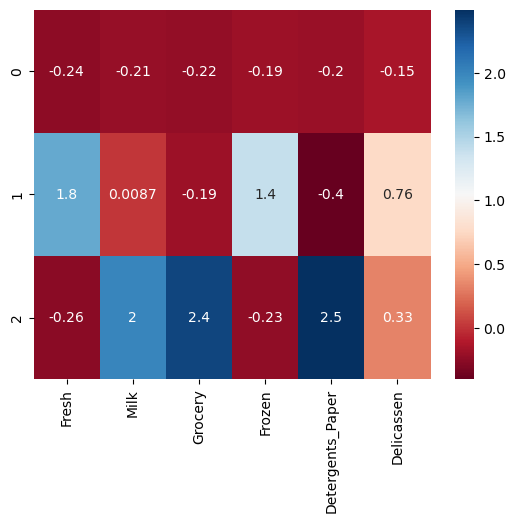

In [63]:
cluster_centers2 = pd.DataFrame(kmeans3.cluster_centers_, columns=data_scaled.columns)
sns.heatmap(cluster_centers2, cmap='RdBu', annot=True);

## 3. Hierarchical Clustering

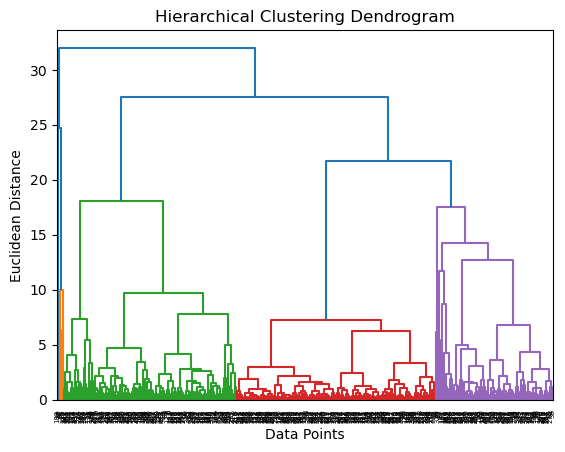

In [65]:
# a. Create a dendrogram using the scaled data
from scipy.cluster.hierarchy import linkage,dendrogram
linkage_matrix = linkage(data_scaled, method='ward')
dendrogram_info = dendrogram(linkage_matrix, color_threshold=20)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance");

In [15]:
# b. Visually identify the number of clusters and update the color threadshold, if necessary


In [66]:
# c. Fit an agglomerative clustering model on the scaled data set with the "best" clusters and view the number of data points in each cluster
from sklearn.cluster import AgglomerativeClustering
agg5=AgglomerativeClustering(5)
agg5.fit(data_scaled)

AgglomerativeClustering(n_clusters=5)

In [67]:
Counter(agg5.labels_)

Counter({np.int64(4): 177,
         np.int64(0): 153,
         np.int64(2): 104,
         np.int64(1): 5,
         np.int64(3): 1})

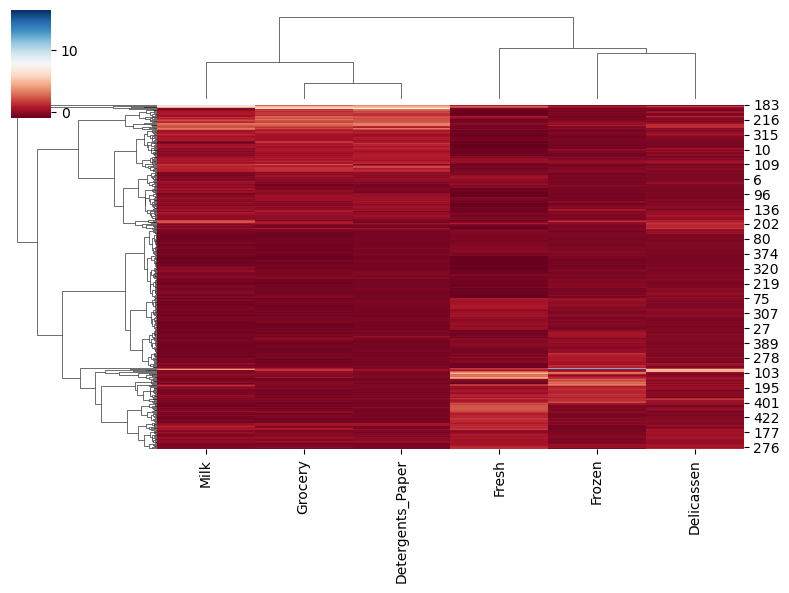

In [68]:
# d. Create a cluster map of the model you just fit
sns.clustermap(data_scaled, method='ward', cmap='RdBu', figsize=(8, 6), xticklabels=data_scaled.columns)
plt.show()

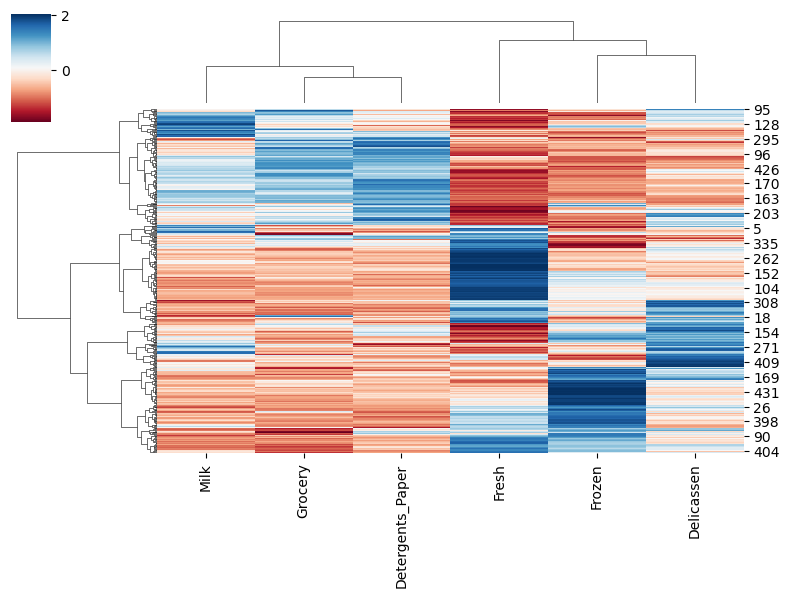

In [69]:
# e. Extra credit: within the clustermap function, add z_score=0 (scales data by row), see what happens and interpret the clusters
sns.clustermap(data_scaled, method='ward', cmap='RdBu', figsize=(8, 6), xticklabels=data_scaled.columns, z_score=0)
plt.show()

In [70]:
# f. Extra credit: write a loop to view the silhouette score for 2 to 20 clusters
agg_silhouette_scores = {}

for n in range(2, 21):
    agg_n = AgglomerativeClustering(n)
    agg_n.fit(data_scaled)
    agg_ss = silhouette_score(data_scaled, agg_n.labels_, metric='euclidean', sample_size=None)
    agg_silhouette_scores[n] = agg_ss

agg_silhouette_scores

{2: np.float64(0.7924572758342273),
 3: np.float64(0.2646091480214908),
 4: np.float64(0.2670148241989557),
 5: np.float64(0.23988371669170097),
 6: np.float64(0.23424990872738188),
 7: np.float64(0.2440568646459785),
 8: np.float64(0.25203846873433405),
 9: np.float64(0.27202620570114383),
 10: np.float64(0.27954261064916225),
 11: np.float64(0.28015398902140587),
 12: np.float64(0.24562381160303043),
 13: np.float64(0.24647695283235932),
 14: np.float64(0.22903049767293357),
 15: np.float64(0.23084079371143718),
 16: np.float64(0.18896719179943278),
 17: np.float64(0.19599492818636077),
 18: np.float64(0.19549508899836085),
 19: np.float64(0.20219343087967662),
 20: np.float64(0.20160566549699505)}

In [71]:
# g. Extra credit: fit a model with the number of clusters for the highest silhouette score
agg2 = AgglomerativeClustering(2)
agg2.fit(data_scaled)

Counter(agg2.labels_)

Counter({np.int64(0): 434, np.int64(1): 6})

## 4. DBSCAN

In [72]:
# a. Copy over the tune_dbscan function from the demo code
# a. Copy over the tune_dbscan function from the demo code
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def tune_dbscan(data):

    results = []

    # define a range of eps and min_samples values to loop through
    eps_values = np.arange(.1, 2, .1)
    min_samples_values = np.arange(2, 10, 1)

    # loop through the combinations of eps and min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_

            # count the number of clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # count the number of noise points (labeled as -1)
            n_noise = list(labels).count(-1)

            # calculate the silhouette score (excluding noise points)
            if n_clusters > 1:  # silhouette score requires at least 2 clusters
                silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                silhouette = None

            results.append([eps, min_samples, n_clusters, n_noise, silhouette])

    # put the results in a dataframe
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
                                                    "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [73]:
# b. Apply the dbscan function on the scaled data
dbscan_results=tune_dbscan(data_scaled)
dbscan_results.head()

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,8,423,-0.393
1,0.1,3,1,437,NaN
2,0.1,4,0,440,NaN
3,0.1,5,0,440,NaN
4,0.1,6,0,440,NaN


In [74]:
# c. Sort the data by highest silhouette score
dbscan_results.sort_values(by='Silhouette Score', ascending=False)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
136,1.8,2,2,13,0.581583
122,1.6,4,2,24,0.578543
97,1.3,3,3,25,0.424572
96,1.3,2,3,25,0.424572
105,1.4,3,3,23,0.423547
...,...,...,...,...,...
147,1.9,5,1,15,NaN
148,1.9,6,1,18,NaN
149,1.9,7,1,18,NaN
150,1.9,8,1,19,NaN


In [75]:
# d. Notice that the top eps value is close to 2, so update the function to test eps values up to 5 (instead of 2)
def tune_dbscan(data):

    results = []

    # define a range of eps and min_samples values to loop through
    eps_values = np.arange(.1, 5, .1)
    min_samples_values = np.arange(2, 10, 1)

    # loop through the combinations of eps and min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_

            # count the number of clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # count the number of noise points (labeled as -1)
            n_noise = list(labels).count(-1)

            # calculate the silhouette score (excluding noise points)
            if n_clusters > 1:  # silhouette score requires at least 2 clusters
                silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                silhouette = None

            results.append([eps, min_samples, n_clusters, n_noise, silhouette])

    # put the results in a dataframe
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
                                                    "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [76]:
# e. Try applying the function again and view the top silhouette scores
dbscan_results2 = tune_dbscan(data_scaled)
dbscan_results2.head()

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,8,423,-0.393
1,0.1,3,1,437,NaN
2,0.1,4,0,440,NaN
3,0.1,5,0,440,NaN
4,0.1,6,0,440,NaN


In [77]:
# f. Fit a DBSCAN model on the scaled data set with the best eps + min_samples values and view the number of data points in each cluster
dbscan2 = DBSCAN(eps=3.5, min_samples=2)
dbscan2.fit(data_scaled)

DBSCAN(eps=3.5, min_samples=2)

In [78]:
Counter(dbscan2.labels_)

Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})

## 5. Compare Techniques

For each of the following 5 models, fit the model on the scaled data, note down the number of data points in each cluster and record the silhouette score:
1. K-Means with 3 clusters
2. K-Means with 5 clusters
3. Hiearchical Clustering with 2 clusters
4. Hierarchical Clustering with 5 clusters
5. DBSCAN with 2 clusters

In [79]:
def print_metrics(model, data):
    print(model)
    print(Counter(model.labels_))
    print(silhouette_score(data, model.labels_))

In [80]:
print_metrics(kmeans3, data_scaled) # differentiated, simple and interpretable

KMeans(n_clusters=3, random_state=42)
Counter({np.int32(0): 350, np.int32(1): 53, np.int32(2): 37})
0.4582633767207058


In [81]:
print_metrics(kmeans5, data_scaled) # decent model

KMeans(n_clusters=5, random_state=42)
Counter({np.int32(3): 272, np.int32(0): 96, np.int32(1): 59, np.int32(2): 11, np.int32(4): 2})
0.36890127429678055


In [82]:
print_metrics(agg2, data_scaled) # very few differentiated points

AgglomerativeClustering()
Counter({np.int64(0): 434, np.int64(1): 6})
0.7924572758342273


In [83]:
print_metrics(agg5, data_scaled) # mainly three clusters

AgglomerativeClustering(n_clusters=5)
Counter({np.int64(4): 177, np.int64(0): 153, np.int64(2): 104, np.int64(1): 5, np.int64(3): 1})
0.23988371669170097


In [85]:
print_metrics(dbscan2, data_scaled) # very few differentiated points

DBSCAN(eps=3.5, min_samples=2)
Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})
0.740283564230615


## 6. Recommend Client Segments

In [86]:
# a. With the top model as the K-Means model with 3 clusters, review the results again
kmeans3 = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans3.fit(data_scaled)

KMeans(n_clusters=3, random_state=42)

In [87]:
Counter(kmeans3.labels_)

Counter({np.int32(0): 350, np.int32(1): 53, np.int32(2): 37})

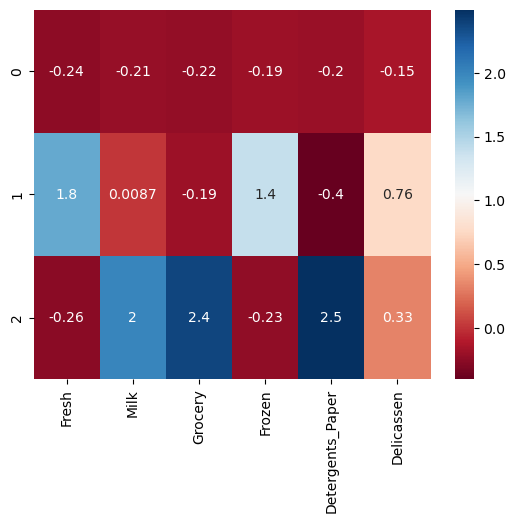

In [88]:
# view the cluster centers
cluster_centers3 = pd.DataFrame(kmeans3.cluster_centers_, columns=data_scaled.columns)
sns.heatmap(cluster_centers3, cmap='RdBu', annot=True);

# b. Clearly state what you would recommend as client segments and how you would better support those clients
* **Typical clients**: make sure our sales team is knowledgeable about a variety of products
* **Clients who purchase a lot of fresh and frozen foods**: make sure to prioritize these clients when shipping them fresh foods
* **Clients who purchase a lot of milk, grocery, detergents and paper items**: make sure to keep them up to date on new non-perishable items

## 7. Predict the Cluster of a New Client

In [93]:
# a. Given this new client, determine which cluster they fall into
import pandas as pd
import numpy as np

new_client = pd.DataFrame([np.array([15000, 15000, 30000, 500, 15000, 2000])],
                          columns=['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'])
new_client

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,15000,15000,30000,500,15000,2000


In [94]:
# b. Scale the new client data using the same scaler object from the Data Prep step
new_client_scaled = pd.DataFrame(sc.transform(new_client), columns=data.columns)
new_client_scaled

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.237451,1.248474,2.322787,-0.530388,2.544604,0.168671


In [95]:
# c. Make a prediction using the K-Means model with 3 clusters
kmeans3.predict(new_client_scaled)

array([2], dtype=int32)

In [32]:
# d. Which cluster does the new client belong to?
